<a href="https://colab.research.google.com/github/parask29/Credit-Card-Fraud-Detection_ML-XGBoost/blob/main/Credit_card_fraud_detection_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df1 = pd.read_csv('/content/fraudTest.csv')
df2 = pd.read_csv('/content/fraudTrain.csv')

df1.shape, df2.shape

((555719, 23), (1296675, 23))

In [4]:
df = pd.concat([df1, df2], ignore_index=True)

In [5]:
df.shape

(1852394, 23)

In [6]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [7]:
df[df['is_fraud'] == 1].shape[0]*100/df.shape[0]

# Out of all rows, only 0.5% is fraud, 99.5% non-fraud. So data is highly imbalanced

0.5210014716091717

## Feature Engineering

In [8]:
# Time feature -- trans_date_trans_time  , dob,
# Age
# Distance

In [9]:
import datetime as dt
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df['dob'] = pd.to_datetime(df['dob'])

df['hour'] = df['trans_date_trans_time'].dt.hour

df['day'] = df['trans_date_trans_time'].dt.day

df['month'] = df['trans_date_trans_time'].dt.month

In [10]:
df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year

In [11]:
df.isna().sum()
df.dropna(inplace = True)

In [12]:
df['age'] = df['age'].astype('int32')

In [13]:
# Distance between merchant and user-- How far transaction has taken place......
df['Distance'] = ((df['lat'] - df['merch_lat'])**2 + (df['long'] -df['merch_long'])**2)

## Feature encoding





In [14]:
## Drop useless Column


drop_cols = ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'zip', 'dob', 'trans_num', 'unix_time', 'city', 'trans_date_trans_time']

In [15]:
df.drop(columns=drop_cols, inplace = True, errors = 'ignore')

In [16]:
print(df.columns.to_list())

['merchant', 'category', 'amt', 'gender', 'state', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'hour', 'day', 'month', 'age', 'Distance']


In [17]:
# Categorical Columns

df_categorical = ['merchant', 'category', 'gender','state', 'job']

In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for i in df_categorical:
  df[i] = le.fit_transform(df[i])

In [19]:
df.head()

,merchant,category,amt,gender,state,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,day,month,age,Distance
0,319,10,2.86,1,40,33.9659,-80.9355,333497,288,33.986391,-81.200714,0,12,21,6,52,0.070758
1,591,10,29.84,0,44,40.3207,-110.4360,302,406,39.450498,-109.960431,0,12,21,6,30,0.983417
2,611,5,41.28,0,34,40.6729,-73.5365,34496,272,40.495810,-74.196111,0,12,21,6,50,0.466448
3,222,9,60.05,1,9,28.5697,-80.8191,54767,422,28.812398,-80.883061,0,12,21,6,33,0.062993
4,292,13,3.19,1,22,44.2529,-85.0170,1126,205,44.959148,-85.884734,0,12,21,6,65,1.251749


## Model Creation

In [20]:
# Data is imbalance --
##  1. keeps the fraud percentage identical in both splits, Y_Train and Y_Test == Use 'stratify=y'
##  2. class weights balancing = Use 'scale_pos_weight '
# use scale_pos_weight = Total negative/total positive

In [21]:
from sklearn.model_selection import train_test_split
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [22]:
y_train.mean(), y_test.mean()   # Same Fraud percentage

(np.float64(0.005210150379745127), np.float64(0.005209472061844261))

In [23]:
from xgboost import XGBClassifier

In [24]:
fraud_count = int(y_train.sum())
nonfraud_count = int((y_train==0).sum())

scale_pos_weight = nonfraud_count/fraud_count
scale_pos_weight

190.9330397616889

In [25]:
nonfraud_count

1474194

In [26]:
model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    tree_method='hist',                 # faster on large datasets
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=20
)

print('Model trained.')

[0]	validation_0-aucpr:0.30353
[20]	validation_0-aucpr:0.85110
[40]	validation_0-aucpr:0.86905
[60]	validation_0-aucpr:0.88702
[80]	validation_0-aucpr:0.90297
[100]	validation_0-aucpr:0.90931
[120]	validation_0-aucpr:0.91328
[140]	validation_0-aucpr:0.91663
[160]	validation_0-aucpr:0.91818
[180]	validation_0-aucpr:0.92111
[199]	validation_0-aucpr:0.92475
Model trained.


## Model Evaluation

Metrics


1.   Accuracy  --- Not good as data is imbalanced
2.   Precision ---
3.  Recall
4. F1score
5. ROC-AUC



In [27]:
y_pred = model.predict(X_test)
y_probab = model.predict_proba(X_test)[:,1]

In [28]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
Accuracy = accuracy_score(y_test, y_pred)  # Not good metric as data is highly imbalanced
Accuracy

0.9909927418288216

In [29]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.99      1.00    368549
           1       0.36      0.96      0.53      1930

    accuracy                           0.99    370479
   macro avg       0.68      0.98      0.76    370479
weighted avg       1.00      0.99      0.99    370479



In [30]:
roc_auc_score(y_test, y_probab)

np.float64(0.9985610029259543)

<Axes: >

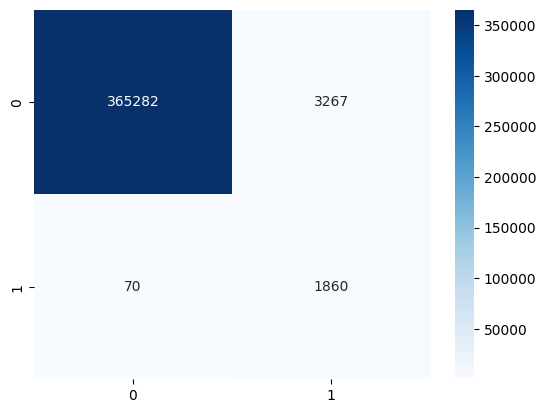

In [31]:
# Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_mat, annot= True, cmap = 'Blues', fmt = 'd')

## Feature Importance

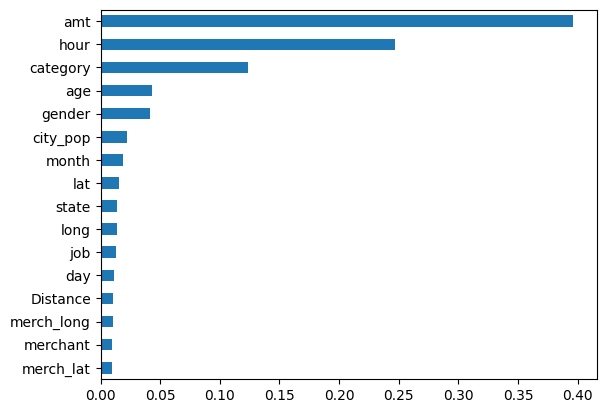

In [32]:
feat_importance = pd.Series(model.feature_importances_, index = X_train.columns).sort_values().plot(kind = 'barh')



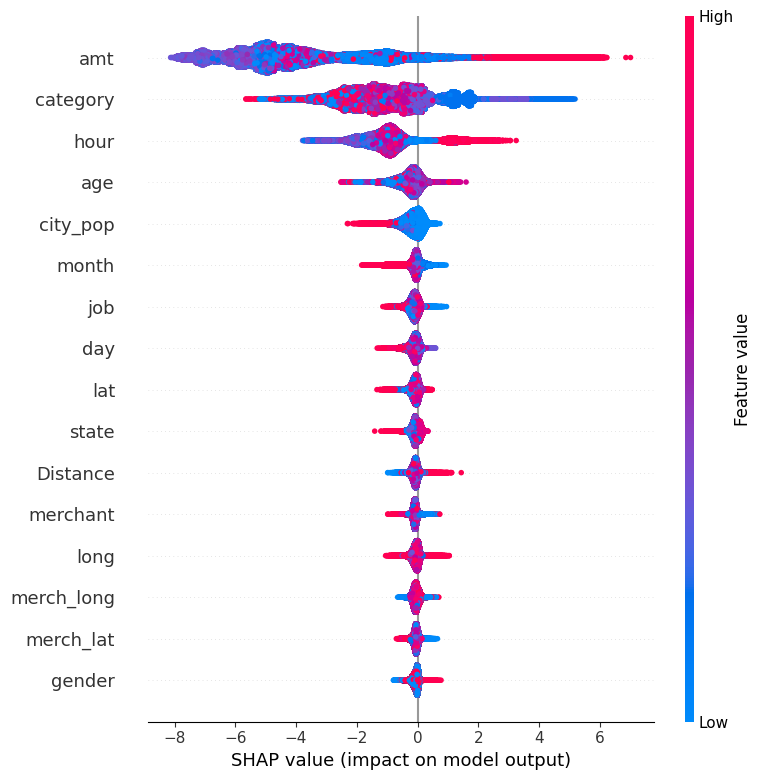

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)